# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:**  Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [3]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

for name,model in base_models.items() :
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_macro'
    )

    baseline_results[name] = (scores.mean(), scores.std())


# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [5]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C': [0.1,1,10,100],
    'svm__gamma': ['scale',0.1,0.001],
    'svm__kernel': ['rbf','linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(estimator=svm_pipe, param_grid=svm_param_grid, cv=5, scoring='f1_macro',n_jobs=-1)
svm_grid_search.fit(X_train,y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Лучший CV F1: 0.9762


In [6]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

svm_results = pd.DataFrame(svm_grid_search.cv_results_)

top10_svm = svm_results[['params','mean_test_score','std_test_score','rank_test_score']].sort_values('rank_test_score').head(10)

display(top10_svm)

,params,mean_test_score,std_test_score,rank_test_score
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,1
3,"{'svm__C': 0.1, 'svm__gamma': 0.1, 'svm__kerne...",0.976215,0.015266,1
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,1
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,4
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,5
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,6
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,7
7,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.964626,0.014950,8
9,"{'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel'...",0.964626,0.014950,8
11,"{'svm__C': 1, 'svm__gamma': 0.001, 'svm__kerne...",0.964626,0.014950,8


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2,20),
    'min_samples_split': randint(2,20),
    'max_features': ['sqrt','log2',0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

rf_random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_distributions=rf_param_dist,
                           n_iter=50, cv=5, scoring='f1_macro',random_state=42,n_jobs=-1)

rf_random_search.fit(X_train,y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [8]:
from sklearn.metrics import classification_report

test_results = {}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

models_to_eveluate = {
    'SVM baseline': base_models['SVM'].fit(X_train,y_train),
    'SVM Grid Search': svm_grid_search.best_estimator_,
    'RF baseline': base_models['RandomForest'].fit(X_train,y_train),
    'RF Random Search': rf_random_search.best_estimator_
}

for name,model in models_to_eveluate.items():
    y_pred = model.predict(X_test)
    test_f1 = f1_score(y_test,y_pred,average='macro')
    test_results[name] = test_f1

    print(f"\n{name}")
    print(f"Test F1 macro: {test_f1:.4f}")
    print(classification_report(y_test,y_pred,target_names=data.target_names))


comparison_table = pd.DataFrame({
    'Model': [
        'SVM baseline',
        'SVM Grid Search',
        'RF baseline',
        'RF Random Search'
    ],
    'CV F1 macro': [
        f"{baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f}",
        f"{svm_grid_search.best_score_:.4f}",
        f"{baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f}",
        f"{rf_random_search.best_score_:.4f}",
    ],
    'Test F1 macro': [
        f"{test_results['SVM baseline']:.4f}",
        f"{test_results['SVM Grid Search']:.4f}",
        f"{test_results['RF baseline']:.4f}",
        f"{test_results['RF Random Search']:.4f}",
    ],
    'Best params': [
        'default',
        str(svm_grid_search.best_params_),
        'default',
        str(rf_random_search.best_params_),
    ]
})

pd.set_option('display.max_colwidth', None)

display(
    comparison_table.style
    .hide(axis='index')
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'pre-wrap'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'left'),
            ('font-weight', 'bold')
        ]},
        {'selector': 'td', 'props': [
            ('padding', '8px 12px')
        ]}
    ])
)

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |


SVM baseline
Test F1 macro: 0.9812
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


SVM Grid Search
Test F1 macro: 0.9812
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


RF baseline
Test F1 macro: 0.9526
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg      

Model,CV F1 macro,Test F1 macro,Best params
SVM baseline,0.9694 ± 0.0193,0.9812,default
SVM Grid Search,0.9762,0.9812,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}"
RF baseline,0.9504 ± 0.0255,0.9526,default
RF Random Search,0.9554,0.9526,"{'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}"


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

,feature,importance_mean,importance_std
23,worst area,0.010087,0.012118
27,worst concave points,0.008251,0.006404
21,worst texture,0.006430,0.004209
4,mean smoothness,0.005511,0.004500
3,mean area,0.005503,0.006076
26,worst concavity,0.004593,0.004593
1,mean texture,0.003674,0.004500
7,mean concave points,0.003674,0.004500
25,worst compactness,0.002756,0.004209
24,worst smoothness,0.002756,0.004209


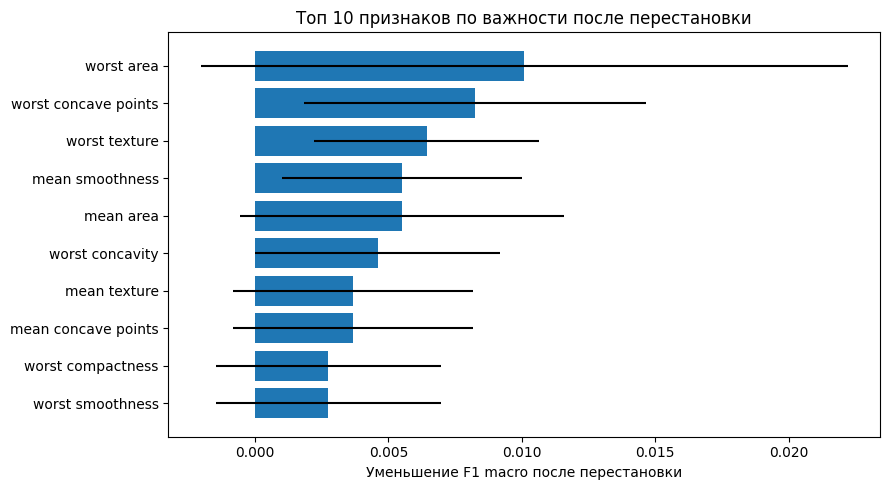

In [9]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

pi_result = permutation_importance(best_rf,X_test,y_test,n_repeats=10,random_state=42,scoring='f1_macro')

# Построим bar plot топ-10 признаков

#делаем датафрейм с pi
pi_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': pi_result.importances_mean,
    'importance_std': pi_result.importances_std
})

# сортируем признаки по важности
pi_df = pi_df.sort_values('importance_mean',ascending=False)

# консолим топ-10 признаков
display(pi_df.head(10))

# переворачиваем порядок для bar plot чтобы самый важный был сверху
top10_pi = pi_df.head(10)[::-1]

plt.figure(figsize=(9,5))
plt.barh(
    top10_pi['feature'],
    top10_pi['importance_mean'],
    xerr=top10_pi['importance_std']
)
plt.xlabel('Уменьшение F1 macro после перестановки')
plt.title('Топ 10 признаков по важности после перестановки')
plt.tight_layout()
plt.show()

In [13]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

rf_importance_df = pd.DataFrame({
    'feature': feature_names,
    'rf_importance' : best_rf.feature_importances_
})

#cортируем по встроенной важности
rf_importance_df = rf_importance_df.sort_values('rf_importance',ascending=False)

# выводим топ-10 признаков rf_importance__
display(rf_importance_df.head(10))

#объединяем PI и feature_importances__ у RF
importance_comparison = (
    pi_df[['feature','importance_mean','importance_std']].merge(rf_importance_df,on='feature')
)

importance_comparison['rank_pi'] = importance_comparison['importance_mean'].rank(
    ascending=False,
    method='min'
).astype(int)

importance_comparison['rank_rf'] = importance_comparison['rf_importance'].rank(
    ascending=False,
    method='min'
).astype(int)

# cортируем по Permutation Importance и выводим таблицу сравнения
importance_comparison = importance_comparison.sort_values('rank_pi')

display(importance_comparison.head(10))

top5_pi = (
    importance_comparison.sort_values('rank_pi').head(5)['feature'].tolist()
)

top5_rf = (
    importance_comparison.sort_values('rank_rf').head(5)['feature'].tolist()
)

common_top5 = set(top5_pi) & set(top5_rf)

print("Top-5 по Permutation Importance :")
print(top5_pi)

print("Top-5 по rf_importance :")
print(top5_rf)

print("Общие признакми в top-5")
print(list(common_top5))

print(f"Совпало {len(common_top5)} из 5 признаков")
# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

,feature,rf_importance
23,worst area,0.127064
22,worst perimeter,0.114167
27,worst concave points,0.109349
20,worst radius,0.082528
7,mean concave points,0.072224
0,mean radius,0.058359
3,mean area,0.054590
2,mean perimeter,0.053268
6,mean concavity,0.052139
13,area error,0.044255


,feature,importance_mean,importance_std,rf_importance,rank_pi,rank_rf
0,worst area,0.010087,0.012118,0.127064,1,1
1,worst concave points,0.008251,0.006404,0.109349,2,3
2,worst texture,0.006430,0.004209,0.018821,3,14
3,mean smoothness,0.005511,0.004500,0.008394,4,21
4,mean area,0.005503,0.006076,0.054590,5,7
5,worst concavity,0.004593,0.004593,0.034881,6,11
6,mean texture,0.003674,0.004500,0.014068,7,17
7,mean concave points,0.003674,0.004500,0.072224,7,5
8,worst compactness,0.002756,0.004209,0.019765,9,12
9,worst smoothness,0.002756,0.004209,0.014292,9,16


Top-5 по Permutation Importance :
['worst area', 'worst concave points', 'worst texture', 'mean smoothness', 'mean area']
Top-5 по rf_importance :
['worst area', 'worst perimeter', 'worst concave points', 'worst radius', 'mean concave points']
Общие признакми в top-5
['worst area', 'worst concave points']
Совпало 2 из 5 признаков


Различия заметны как минимум потому, что методы измеряют и выполняют разные задачи. Объяснить можно дефолтной корреляцией признаков, то ессть PI может быть низким так как признак дублируется другим, в то время как rf_importance может иметь значение в разы выше

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

Топ-3 признака по PI
[np.str_('worst area'), np.str_('worst concave points'), np.str_('worst texture')]


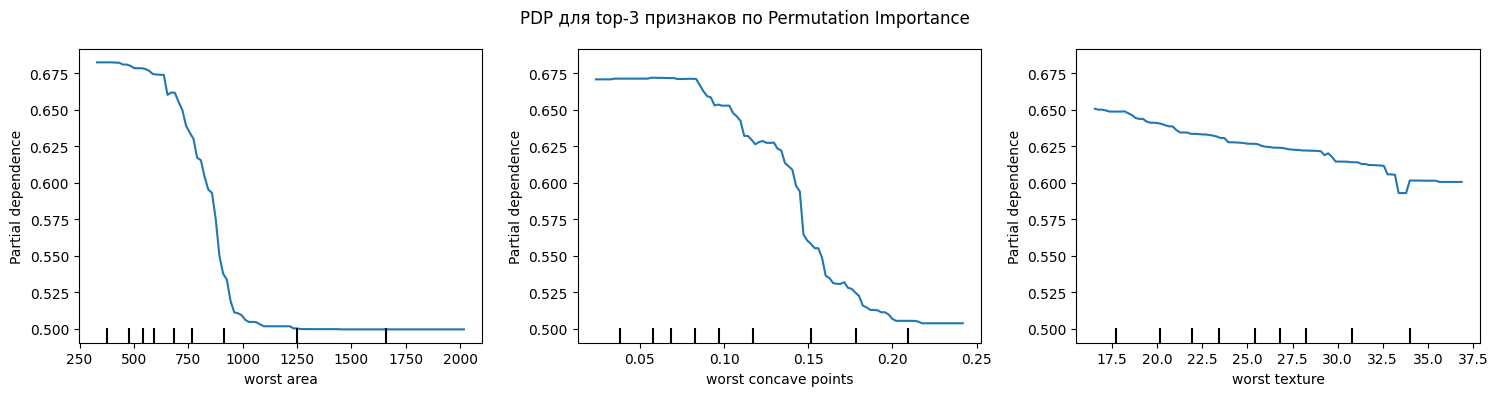

In [14]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = np.argsort(pi_result.importances_mean)[-3:][::-1]
top3_features = feature_names[top3_idx]

print("Топ-3 признака по PI")
print(list(top3_features))

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_train,
    kind='average',
    features=top3_features,
    ax=ax
)
plt.suptitle('PDP для top-3 признаков по Permutation Importance')
plt.tight_layout()
plt.show()

Самый важный признак worst area


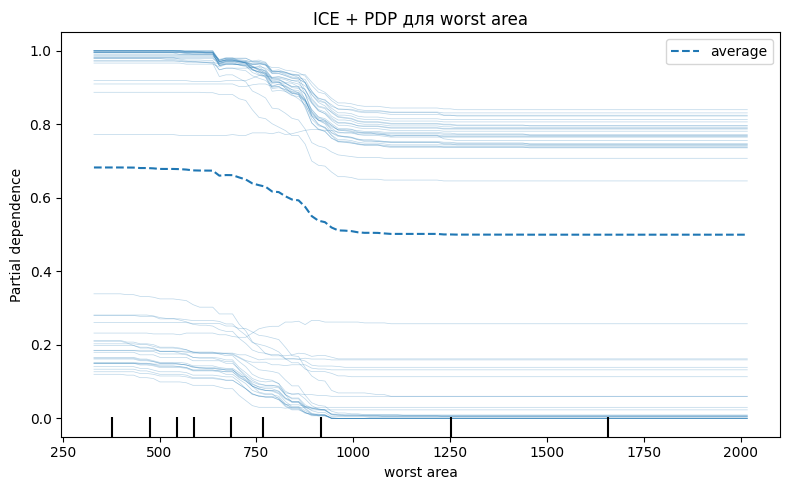

In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

most_important_feature = top3_features[0]

print(f"Самый важный признак {most_important_feature}")

fig,ax = plt.subplots(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    best_rf,
    X_train,
    features=[most_important_feature],
    kind='both',
    subsample=50,
    random_state=42,
    ax=ax
)

plt.title(f"ICE + PDP для {most_important_feature}")
plt.tight_layout()
plt.show()


## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [18]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap
shap.initjs()
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝


explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(114, 30, 2)


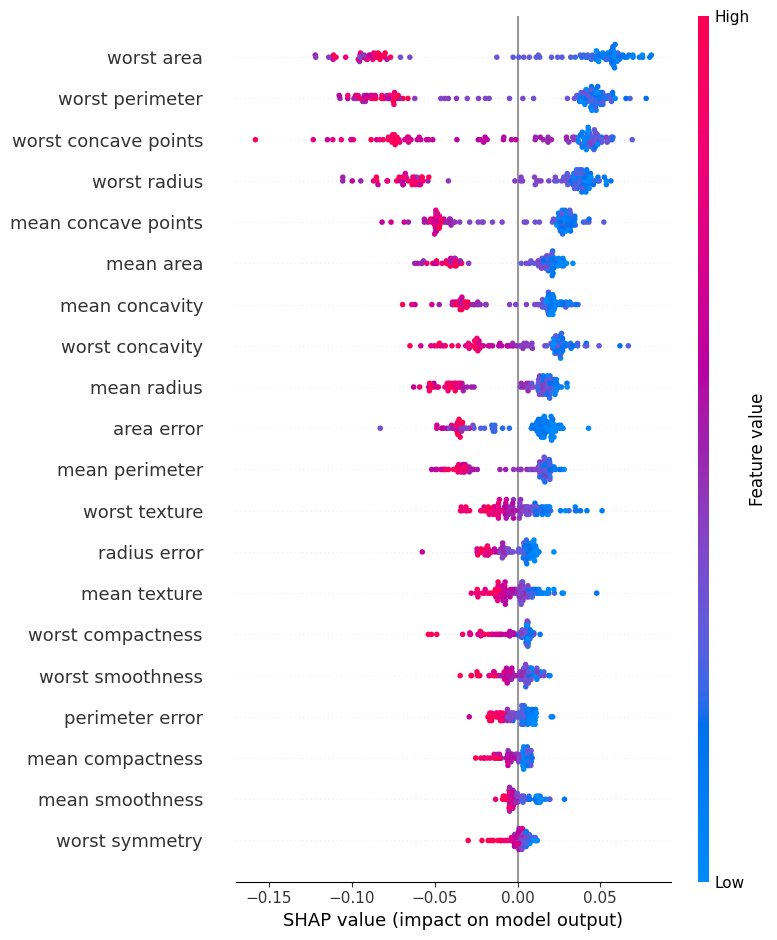

In [19]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

class_id = 1

if isinstance(shap_values,list):
    shap_values_class = shap_values[class_id]
else:
    shap_values_class = shap_values[:,:, class_id]

shap.summary_plot(
    shap_values_class,
    X_test,
    feature_names=feature_names
)

SHAP и Permutation Importance частично согласуются: среди важных признаков снова есть worst area, worst concave points, worst texture/texture-related признаки. 
Но SHAP выше поднимает worst perimeter, worst radius и mean concave points. Это нормально, потому что SHAP распределяет вклад между признаками внутри модели, а PI измеряет падение качества после перемешивания признака.

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


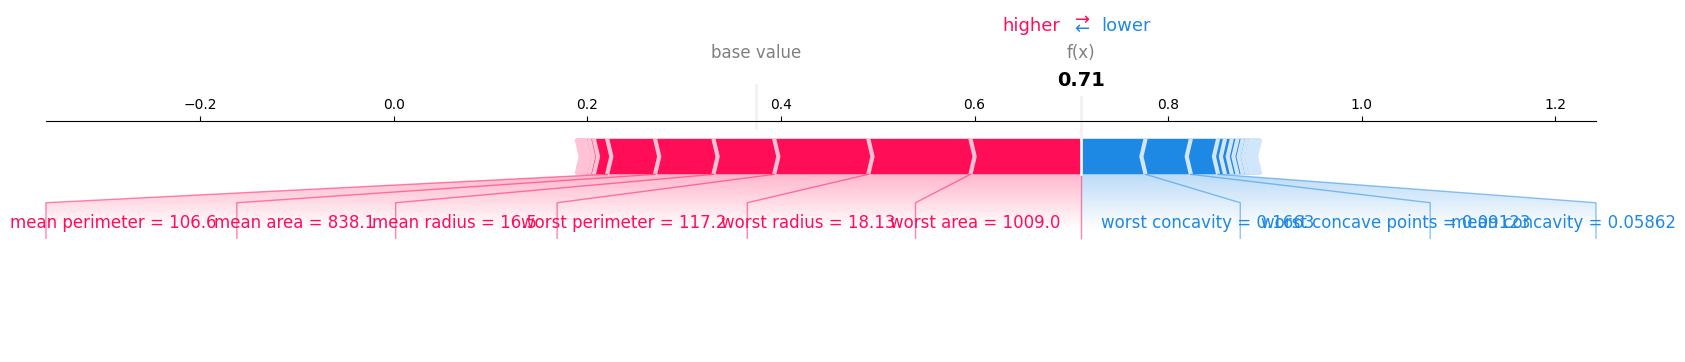

In [20]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]
error_idx = errors[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {error_idx}")
print(f"  Истинный класс: {y_test.iloc[error_idx]}")
print(f"  Предсказанный класс: {y_pred_test[error_idx]}")

class_to_explain = y_pred_test[error_idx]

# Достаём SHAP values для предсказанного класса
if isinstance(shap_values, list):
    shap_values_for_class = shap_values[class_to_explain]
    expected_value = explainer.expected_value[class_to_explain]
else:
    shap_values_for_class = shap_values[:, :, class_to_explain]
    expected_value = explainer.expected_value[class_to_explain]

# Строим force plot для ошибочного объекта.
shap.force_plot(
    expected_value,
    shap_values_for_class[error_idx],
    X_test.iloc[error_idx],
    matplotlib=True
)

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [21]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# Обучаем RandomForest на данных с двумя новыми признаками:
# leaky_feature почти равен target, поэтому это утечка данных;
# random_feature — просто случайный шум.
rf_suspicious = RandomForestClassifier(
    random_state=42,
    n_estimators=300
)

rf_suspicious.fit(X_train_ext,y_train)

# Проверяем качество на тесте.
# Если leaky_feature попал и в train, и в test, качество может стать почти идеальным,
# потому что модель фактически видит target через этот признак.
y_pred_suspicious = rf_suspicious.predict(X_test_ext)

print("Test F1 macro:", f1_score(y_test, y_pred_suspicious, average='macro'))
print(classification_report(y_test, y_pred_suspicious, target_names=data.target_names))


Test F1 macro: 1.0
              precision    recall  f1-score   support

   malignant       1.00      1.00      1.00        42
      benign       1.00      1.00      1.00        72

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



In [24]:
# Считаем Permutation Importance.
# Для каждого признака sklearn перемешивает его значения
# и смотрит, насколько падает F1 macro.
# Если leaky_feature важен, его перемешивание должно резко ухудшить качество.
pi_suspicious = permutation_importance(
    rf_suspicious,
    X_test_ext,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

pi_suspicious_df = pd.DataFrame({
    'feature': X_train_ext.columns,
    'importance_mean': pi_suspicious.importances_mean,
    'importance_std': pi_suspicious.importances_std
}).sort_values('importance_mean', ascending=False)

display(pi_suspicious_df.head(10))

,feature,importance_mean,importance_std
30,leaky_feature,0.295286,0.044793
26,worst concavity,0.005627,0.004595
0,mean radius,0.000000,0.000000
1,mean texture,0.000000,0.000000
4,mean smoothness,0.000000,0.000000
5,mean compactness,0.000000,0.000000
2,mean perimeter,0.000000,0.000000
3,mean area,0.000000,0.000000
8,mean symmetry,0.000000,0.000000
9,mean fractal dimension,0.000000,0.000000


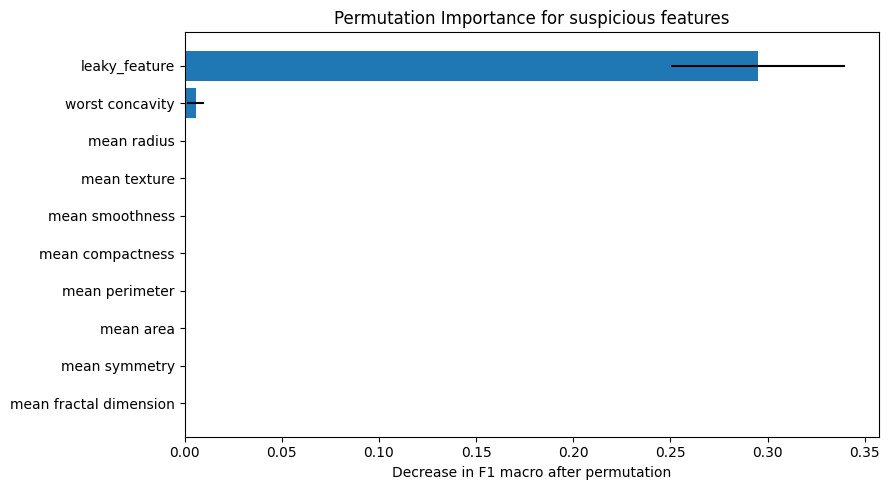

In [25]:
# Строим график Permutation Importance.
# На нём leaky_feature должен быть одним из самых важных признаков,
# а random_feature должен быть около нуля.
top10_suspicious = pi_suspicious_df.head(10).iloc[::-1]

plt.figure(figsize=(9, 5))
plt.barh(
    top10_suspicious['feature'],
    top10_suspicious['importance_mean'],
    xerr=top10_suspicious['importance_std']
)
plt.xlabel('Decrease in F1 macro after permutation')
plt.title('Permutation Importance for suspicious features')
plt.tight_layout()
plt.show()

In [ ]:
# Считаем SHAP values для модели с подозрительными признаками.
# SHAP покажет, какие признаки сильнее всего влияли на предсказания.
explainer_suspicious = shap.TreeExplainer(rf_suspicious)
shap_values_suspicious = explainer_suspicious.shap_values(X_test_ext)

print(type(shap_values_suspicious))
print(np.array(shap_values_suspicious).shape)

<class 'numpy.ndarray'>
(114, 32, 2)


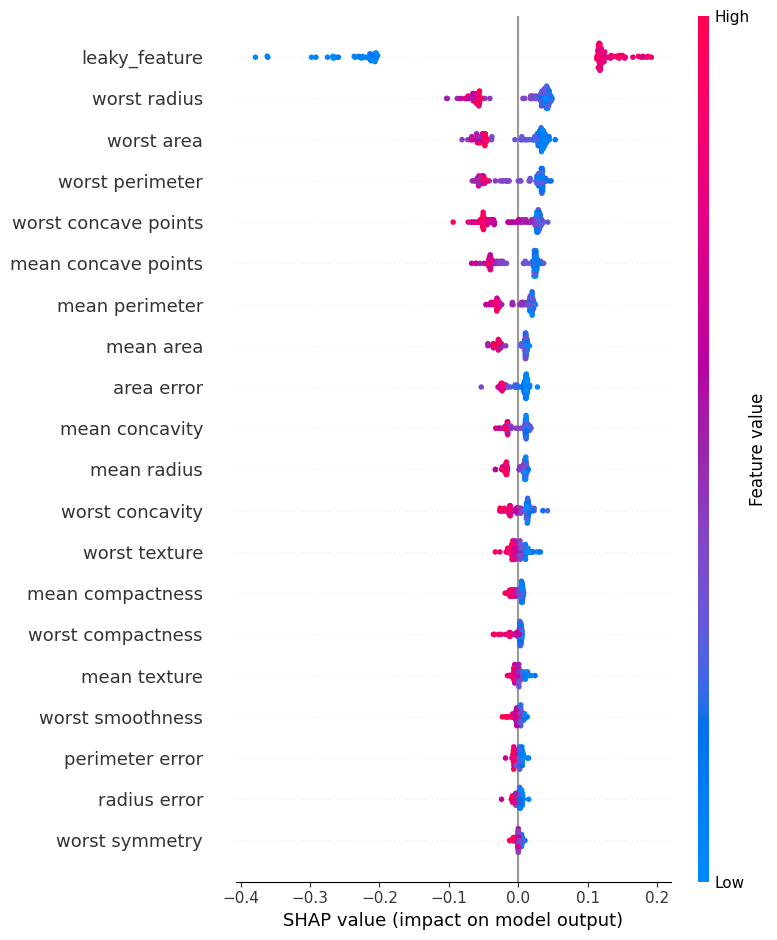

In [27]:
# Достаём SHAP values для класса 1.
# В датасете Breast Cancer класс 1 — benign.
if isinstance(shap_values_suspicious, list):
    shap_values_suspicious_class = shap_values_suspicious[1]
else:
    shap_values_suspicious_class = shap_values_suspicious[:, :, 1]

# Строим SHAP summary plot.
# Если leaky_feature наверху, значит модель сильно опирается на утечку.
shap.summary_plot(
    shap_values_suspicious_class,
    X_test_ext,
    feature_names=X_train_ext.columns
)

a) Permutation Importance должна определить leaky_feature как очень важный признак: при его перемешивании качество модели резко падает. 
Метрика на тесте выросла, потому что leaky_feature почти напрямую содержит правильный ответ, то есть модель получила утечку target.

б) В SHAP summary plot leaky_feature должен оказаться среди самых верхних признаков. Это значит, что он даёт большой вклад в предсказания модели.

в) random_feature можно обнаружить как шумовой по низкой важности: его Permutation Importance должна быть около нуля, а SHAP-вклад маленьким. Если перемешивание признака почти не меняет качество, значит модель от него практически не зависит.

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [28]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# Собираем финальную таблицу по всем основным моделям.
# CV F1 берём из baseline_results и search-объектов.
# Test F1 берём из test_results, который мы сделали в шаге 5.
summary_table = pd.DataFrame({
    'Метод': [
        'SVM baseline',
        'SVM Grid Search',
        'RF baseline',
        'RF Random Search'
    ],
    'CV F1': [
        f"{baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f}",
        f"{svm_grid_search.best_score_:.4f}",
        f"{baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f}",
        f"{rf_random_search.best_score_:.4f}",
    ],
    'Test F1': [
        f"{test_results['SVM baseline']:.4f}",
        f"{test_results['SVM Grid Search']:.4f}",
        f"{test_results['RF baseline']:.4f}",
        f"{test_results['RF Random Search']:.4f}",
    ],
    'Выводы': [
        'Базовая SVM уже даёт сильный результат',
        'Подбор параметров уточняет C, gamma и kernel',
        'Базовый RandomForest устойчив без масштабирования',
        'Random Search подбирает более удачную конфигурацию RF'
    ]
})

# Делаем вывод таблицы красивее и без обрезания текста.
pd.set_option('display.max_colwidth', None)

display(
    summary_table.style
    .hide(axis='index')
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'pre-wrap'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'left'),
            ('font-weight', 'bold')
        ]},
        {'selector': 'td', 'props': [
            ('padding', '8px 12px')
        ]}
    ])
)

Метод,CV F1,Test F1,Выводы
SVM baseline,0.9694 ± 0.0193,0.9812,Базовая SVM уже даёт сильный результат
SVM Grid Search,0.9762,0.9812,"Подбор параметров уточняет C, gamma и kernel"
RF baseline,0.9504 ± 0.0255,0.9526,Базовый RandomForest устойчив без масштабирования
RF Random Search,0.9554,0.9526,Random Search подбирает более удачную конфигурацию RF


### Итоговые выводы

1. Тюнинг гиперпараметров позволил сравнить базовые модели с более точно настроенными версиями.  
Для SVM использовался Grid Search, так как пространство параметров было небольшим.  
Для RandomForest использовался Random Search, потому что у модели больше гиперпараметров и полный перебор был бы дороже.

2. Топ-признаки по Permutation Importance и SHAP пересекаются, но порядок признаков не обязан полностью совпадать.  
Permutation Importance измеряет падение качества после перемешивания признака, а SHAP показывает вклад признаков в отдельные предсказания модели.  
В обоих подходах важными оказались признаки, связанные с размером и формой опухоли, например `worst area` и `worst concave points`.

3. Pipeline нужен, чтобы корректно встроить preprocessing в процесс обучения и кросс-валидации.  
Если масштабировать данные заранее до train/test split или до cross-validation, можно получить утечку информации из validation/test частей.  
Pipeline гарантирует, что `StandardScaler` обучается только на train-fold и затем применяется к validation-fold.

4. В реальном проекте PI и SHAP можно использовать для диагностики модели.  
PI помогает понять, какие признаки реально влияют на качество.  
SHAP помогает объяснять как глобальное поведение модели, так и отдельные предсказания.  
Также эти методы помогают находить подозрительные признаки: например, `leaky_feature` резко выделяется как слишком важный, а `random_feature` должен иметь почти нулевую важность.